In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np
import pandas as pd
import math
import os
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from sklearn import preprocessing
from scipy import linalg
from scipy.spatial import distance
from scipy.stats import norm

In [2]:
def read_cdt(forward_file, reverse_file):
    forward_CDT = [0 for i in range(0, 1000)]
    reverse_CDT = [0 for i in range(0, 1000)]

    Skip_first_row = True
    forward_input = open(forward_file, 'r')
    for line in forward_input:
        if Skip_first_row:
            Skip_first_row = False
            continue
        else:
            pass
        for i in range(0, len(line.split()[2:])):
            forward_CDT[i] = forward_CDT[i] + float(line.split()[i+2])
    forward_input.close()

    Skip_first_row = True
    reverse_input = open(reverse_file, 'r')
    for line in reverse_input:
        if Skip_first_row:
            Skip_first_row = False
            continue
        else:
            pass
        for i in range(0, len(line.split()[2:])):
            reverse_CDT[i] = reverse_CDT[i] + float(line.split()[i+2])
    reverse_input.close()
    return preprocessing.normalize([np.array(forward_CDT[1:-1])])[0], preprocessing.normalize([np.array(reverse_CDT[1:-1])])[0]

def Get_k(array_A, array_B, weights_):
    weights_ = np.array(weights_)
    # return the ratio that minimizes the euclidean distance between A and B.
    if np.sum(array_A) > np.sum(array_B):
        array_large = np.array(array_A)
        array_small = np.array(array_B)
    else:
        array_large = np.array(array_B)
        array_small = np.array(array_A)
    a = sum(array_large**2*weights_)
    b = sum((-2*array_large*array_small)*weights_)
    return -b/(2*a)

def get_keys_from_value(dictionary, value):
    keys = []
    for key, val in dictionary.items():
        if val == value:
            keys.append(key)
    return keys

In [3]:
folder_path = '/Users/rl884/Downloads/SCALE_cdt'
BED_ID = '8599'
files = os.listdir(folder_path)
matching_files = [file for file in files if file.startswith('{}_BED_'.format(BED_ID)) and file.endswith('sense_SCALE.cdt')]

# get the background.
forward_bg, reverse_bg = read_cdt(folder_path+'/{}_BED_{}_BAM_sense_SCALE.cdt'.format(BED_ID,BED_ID), folder_path+'/{}_BED_{}_BAM_anti_SCALE.cdt'.format(BED_ID, BED_ID))
peaks_forward, properties_forward = find_peaks(forward_bg, prominence=np.mean(forward_bg), width=2)
peaks_reverse, properties_reverse = find_peaks(reverse_bg, prominence=np.mean(reverse_bg), width=2)

peaks_forward_bg = {}
peaks_reverse_bg = {}
for i in range(0, len(properties_forward['left_ips'])):
    peaks_forward_bg[str([int(properties_forward['left_ips'][i]), math.ceil(properties_forward['right_ips'][i])])] = properties_forward['prominences'][i]/sum(properties_forward['prominences'])
for i in range(0, len(properties_reverse['left_ips'])):
    peaks_reverse_bg[str([int(properties_reverse['left_ips'][i]), math.ceil(properties_reverse['right_ips'][i])])] = properties_reverse['prominences'][i]/sum(properties_reverse['prominences'])

list_forward_bg = []
weights_forward_bg = []
for each in peaks_forward_bg:
    list_forward_bg.append(np.mean(forward_bg[eval(each)[0]:eval(each)[1]]))
    weights_forward_bg.append(peaks_forward_bg[each])   
list_reverse_bg = []
weights_reverse_bg = []
for each in peaks_reverse_bg:
    list_reverse_bg.append(np.mean(reverse_bg[eval(each)[0]:eval(each)[1]]))
    weights_reverse_bg.append(peaks_reverse_bg[each])  

# loop each protein.
k_forward = []
k_reverse = []
d_forward = []
d_reverse = []
sample_codes = []
counter_report = 1
for each in matching_files:
    sample_codes.append(each)
    file_path = os.path.join(folder_path, each)
    print("{} Processing file:".format(counter_report), file_path)
    forward_CDT, reverse_CDT = read_cdt(file_path, file_path.replace("sense", "anti"))
    peaks_forward, properties_forward = find_peaks(forward_CDT, prominence=np.mean(forward_CDT), width=5)
    peaks_reverse, properties_reverse = find_peaks(reverse_CDT, prominence=np.mean(reverse_CDT), width=5)
    
    list_forward_each = []
    for each in peaks_forward_bg:
        list_forward_each.append(np.mean(forward_CDT[eval(each)[0]:eval(each)[1]]))
    k_forward.append(Get_k(list_forward_bg, list_forward_each, weights_forward_bg))
    list_reverse_each = []
    for each in peaks_reverse_bg:
        list_reverse_each.append(np.mean(reverse_CDT[eval(each)[0]:eval(each)[1]]))
    k_reverse.append(Get_k(list_reverse_bg, list_reverse_each, weights_reverse_bg))
    
    d_forward.append(distance.jensenshannon(forward_bg, forward_CDT))
    d_reverse.append(distance.jensenshannon(reverse_bg, reverse_CDT))
    
    counter_report = counter_report+1

1 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_13445_BAM_sense_SCALE.cdt
2 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_14529_BAM_sense_SCALE.cdt
3 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_20016_BAM_sense_SCALE.cdt
4 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_16598_BAM_sense_SCALE.cdt
5 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_20990_BAM_sense_SCALE.cdt
6 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_12843_BAM_sense_SCALE.cdt
7 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_14182_BAM_sense_SCALE.cdt
8 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_28327_BAM_sense_SCALE.cdt
9 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_14973_BAM_sense_SCALE.cdt
10 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_14765_BAM_sense_SCALE.cdt
11 Processing file: /Users/rl884/Downloads/SCALE_cdt/8599_BED_17049_BAM_sense_SCALE.cdt
12 Processing file: /Users/rl884/Download

In [7]:
nan_indices = [i for i, x in enumerate(d_reverse) if math.isnan(x)] + [i for i, x in enumerate(d_forward) if math.isnan(x)]
d_forward_array = np.array(d_forward)
d_reverse_array = np.array(d_reverse)
d_average = (d_forward_array+d_reverse_array)/2
k_average = (np.array(k_forward)+np.array(k_reverse))/2
while nan_indices != []:
    for each in nan_indices:
        sample_codes.pop(each)
        d_forward.pop(each)
        d_reverse.pop(each)
        k_forward.pop(each)
        k_reverse.pop(each)
    d_forward_array = np.array(d_forward)
    d_reverse_array = np.array(d_reverse)
    d_average = (d_forward_array+d_reverse_array)/2
    k_average = (np.array(k_forward)+np.array(k_reverse))/2
    nan_indices = [i for i, x in enumerate(d_reverse) if math.isnan(x)] + [i for i, x in enumerate(d_forward) if math.isnan(x)]

print(nan_indices)

[]


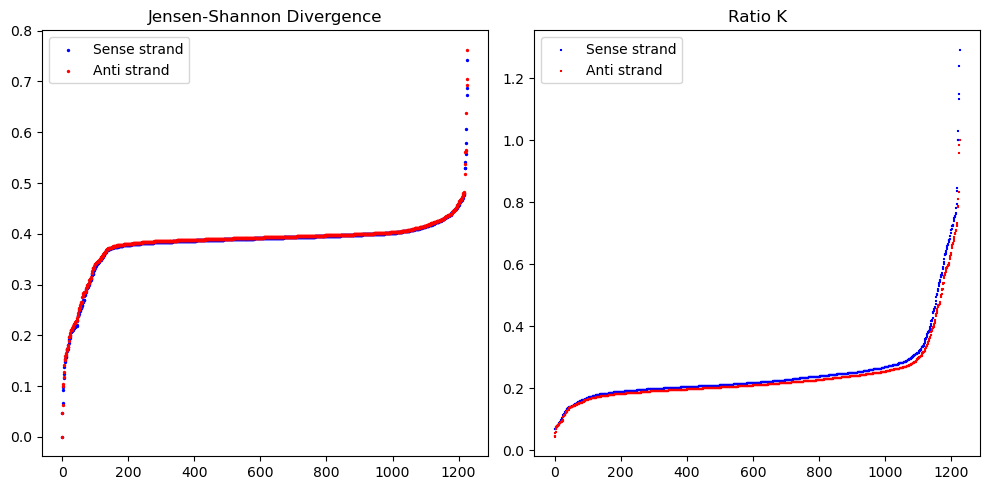

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Plot data on the first subplot
axes[0].scatter(range(0, len(d_forward)), sorted(d_forward), c='b', s=2, label='Sense strand')
axes[0].scatter(range(0, len(d_reverse)), sorted(d_reverse), c='r', s=2, label='Anti strand')
axes[0].set_title('Jensen-Shannon Divergence')
axes[0].legend()

# Plot data on the second subplot
axes[1].scatter(range(0, len(k_forward)), sorted(k_forward), c='b', s=2, marker='+', label='Sense strand')
axes[1].scatter(range(0, len(k_reverse)), sorted(k_reverse), c='r', s=2, marker='+', label='Anti strand')
axes[1].set_title('Ratio K')
axes[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()



In [32]:
def get_slope(array_):
    slope = []
    for i in range(0, len(array_)-1):
        slope.append(abs(array_[i+1] - array_[i]))
    return slope

d_first_derivative = get_slope(sorted(d_average))
d_second_derivative = get_slope(d_first_derivative)
k_first_derivative = get_slope(sorted(k_average))
k_second_derivative = get_slope(k_first_derivative)

# Set the desired probability
probability = 0.9

# Fit distribution parameters (mean and standard deviation)
d_population_mean = np.mean(d_second_derivative[:int(len(d_second_derivative)/2)])
d_population_std = np.std(d_second_derivative[:int(len(d_second_derivative)/2)])
k_population_mean = np.mean(k_second_derivative[int(len(k_second_derivative)/2):])
k_population_std = np.std(k_second_derivative[int(len(k_second_derivative)/2):])

# Find the value such that 90% of the data falls below it.
d_value_normal = norm.ppf(probability, loc=d_population_mean, scale=d_population_std)
k_value_normal = norm.ppf(probability, loc=k_population_mean, scale=k_population_std)

# Return the largest index whose second derivative is larger than the value.
d_index_normal = max(max([index for index, value in enumerate(d_second_derivative[:int(len(d_second_derivative)/2)]) if value > d_value_normal])-1,0)
k_index_normal = min(min([index for index, value in enumerate(k_second_derivative[int(len(k_second_derivative)/2):]) if value > k_value_normal])+int(len(k_second_derivative)/2),len(k_second_derivative))
d_cutoff = sorted(d_average)[d_index_normal]
d_acceptable = np.mean(sorted(d_average)[d_index_normal+1:d_index_normal+31])
k_cutoff = sorted(k_average)[k_index_normal]
print(d_cutoff, d_acceptable, k_cutoff)

0.33123469472211775 0.3484699690754957 0.751517378076825


In [33]:
Selected_indices = []
for each in np.argwhere(k_average>k_cutoff):
    if d_average[each[0]] <= d_acceptable:
        Selected_indices.append([each[0]])
    else:
        continue
for each in np.argwhere(d_average<=d_cutoff):
    if each[0] not in Selected_indices:
        Selected_indices.append([each[0]])
    else:
        continue
Selected_indices = np.array(Selected_indices)
print('{} proteins fall within the d cutoff of {}.'.format(len(np.argwhere(d_average<=d_cutoff)), d_cutoff))
print('{} proteins fall within the k cutoff of {}.'.format(len(np.argwhere(k_average>=k_cutoff)), k_cutoff))
print('{} proteins were acceptable.'.format(len(Selected_indices)))
Selected_Sample_Codes = np.array(sample_codes)[Selected_indices]
k_ratios = np.array(k_forward)[Selected_indices]
d_forward_selected = d_forward_array[Selected_indices]
d_reverse_selected = d_forward_array[Selected_indices]
d_average_selected = (d_reverse_selected+d_forward_selected)/2
SampleKeyFile = open('/Users/rl884/Downloads/SupplementaryData-Table4_Sample-Key_tabular.tab', 'r')
Sample_Keys = {}
for line in SampleKeyFile:
    Sample_Keys[int(line.split()[4])] = line.split()[5]
SampleKeyFile.close()
ClassFile = open('/Users/rl884/Downloads/FeatureClass_Genes.txt', 'r')
Features = {}
for line in ClassFile:
    if len(line.split()) <= 1:
        continue
    elif line.split()[1] == '':
        Features[line.split()[2]] = line.split()[0]
    else:
        Features[line.split()[1]] = line.split()[0]

Features_count = {}
Proteins_selected = {}
for i in range(0, len(Selected_Sample_Codes)):
    Proteins_selected[int(Selected_Sample_Codes[i][0].split('_')[2])] = [k_ratios[i][0], d_average_selected[i][0], Sample_Keys[int(Selected_Sample_Codes[i][0].split('_')[2])].upper()]
    if Sample_Keys[int(Selected_Sample_Codes[i][0].split('_')[2])].upper() in Features:
        #print(Features[Sample_Keys[int(each[0].split('_')[2])].upper()])
        if Features[Sample_Keys[int(Selected_Sample_Codes[i][0].split('_')[2])].upper()] not in Features_count:
            Features_count[Features[Sample_Keys[int(Selected_Sample_Codes[i][0].split('_')[2])].upper()]] = 1
        else:
            Features_count[Features[Sample_Keys[int(Selected_Sample_Codes[i][0].split('_')[2])].upper()]] = Features_count[Features[Sample_Keys[int(Selected_Sample_Codes[i][0].split('_')[2])].upper()]]+1
    else:
        print(Sample_Keys[int(Selected_Sample_Codes[i][0].split('_')[2])].upper()+' not in Features')
if not os.path.exists('/Users/rl884/Downloads/SCALE_cdt/Results/{}/'.format(str(BED_ID)+'_BED')):
    os.makedirs('/Users/rl884/Downloads/SCALE_cdt/Results/{}/'.format(str(BED_ID)+'_BED'))
else:
    pass

YEP_GO = {}
YEP_GO_file = open('/Users/rl884/Downloads/SCALE_cdt/Results/YEP_GO.txt', 'r')
for line in YEP_GO_file:
    YEP_GO[line.split('\t')[0].upper()] = line.split('\t')[1][:-1]
YEP_GO_file.close()

outputfile = open('/Users/rl884/Downloads/SCALE_cdt/Results/{}/{}_Cutoff_{}.txt'.format('{}_BED'.format(BED_ID), '{}_BED'.format(BED_ID), np.round(d_acceptable,3)), 'a')
outputfile.write('YEP_ID\tName\tJS_divergence\tK_ratio\tYEP_Class\tYEP_GO\n')
for each in Proteins_selected:
    if Sample_Keys[each].upper() not in Features and Sample_Keys[each].upper() not in YEP_GO:
        outputfile.write(str(each)+'\t'+str(Proteins_selected[each][2])+'\t'+str(Proteins_selected[each][1])+'\t'+str(Proteins_selected[each][0])+'\n')
    elif Sample_Keys[each].upper() in Features and Sample_Keys[each].upper() not in YEP_GO:
        outputfile.write(str(each)+'\t'+str(Proteins_selected[each][2])+'\t'+str(Proteins_selected[each][1])+'\t'+str(Proteins_selected[each][0])+'\t'+Features[Sample_Keys[each].upper()]+'\n')
    elif Sample_Keys[each].upper() in YEP_GO and Sample_Keys[each].upper() not in Features:
        outputfile.write(str(each)+'\t'+str(Proteins_selected[each][2])+'\t'+str(Proteins_selected[each][1])+'\t'+str(Proteins_selected[each][0])+'\t'+'\t'+YEP_GO[Sample_Keys[each].upper()]+'\n')
    else:
        outputfile.write(str(each)+'\t'+str(Proteins_selected[each][2])+'\t'+str(Proteins_selected[each][1])+'\t'+str(Proteins_selected[each][0])+'\t'+Features[Sample_Keys[each].upper()]+'\t'+YEP_GO[Sample_Keys[each].upper()]+'\n')
outputfile.close()



99 proteins fall within the d cutoff of 0.33123469472211775.
11 proteins fall within the k cutoff of 0.751517378076825.
99 proteins were acceptable.
CTDSER5 not in Features
CTDSER7 not in Features
CTDSER5 not in Features
CTDSER7 not in Features
YDR1 not in Features


TypeError: unsupported operand type(s) for /: 'list' and 'int'

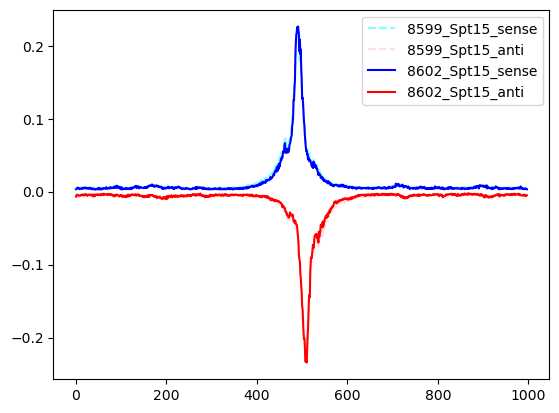

In [35]:
for each in Selected_Sample_Codes:
    file_path = os.path.join(folder_path, '{}_BED_{}_BAM_sense_SCALE.cdt'.format(BED_ID, each[0].split('_')[2]))
    forward_CDT, reverse_CDT = read_cdt(file_path, file_path.replace("sense", "anti"))
    plt.plot(gaussian_filter(forward_bg, sigma=0), c='cyan', alpha=0.5, linestyle='--', label=BED_ID+'_{}'.format(Sample_Keys[int(BED_ID)])+'_sense')
    plt.plot(-gaussian_filter(reverse_bg, sigma=0), c='pink', alpha=0.5, linestyle='--', label=BED_ID+'_{}'.format(Sample_Keys[int(BED_ID)])+'_anti')
    plt.plot(gaussian_filter(forward_CDT, sigma=0), c='b', label=each[0].split('_')[2]+'_{}'.format(Sample_Keys[int(each[0].split('_')[2])])+'_sense')
    plt.plot(-gaussian_filter(reverse_CDT, sigma=0), c='r', label=each[0].split('_')[2]+'_{}'.format(Sample_Keys[int(each[0].split('_')[2])])+'_anti')
    plt.legend()
    plt.title("Jensen-Shannon Divergence={}, ".format(np.round(Proteins_selected[int(each[0].split('_')[2])][1],2)) + 'K_ratio={}'.format(np.round(Proteins_selected[int(each[0].split('_')[2])][0],2)))
    plt.savefig('/Users/rl884/Downloads/SCALE_cdt/Results/{}/{}_{}_Cutoff_{}.png'.format(str(BED_ID)+'_BED', str(BED_ID)+'_BED', each[0].split('_')[2], np.round(d_acceptable,3)))
    plt.close()

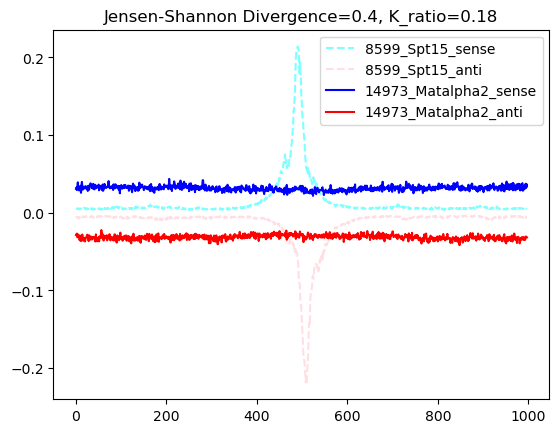

In [46]:
Selected_Sample_Codes_to_plot = np.array([['8599_BED_14973_BAM_sense_SCALE.cdt']])
k_forward_ = []
k_reverse_ = []
d_forward_ = []
d_reverse_ = []

for each in Selected_Sample_Codes_to_plot:
    file_path = os.path.join(folder_path, '{}_BED_{}_BAM_sense_SCALE.cdt'.format(BED_ID, each[0].split('_')[2]))
    forward_CDT, reverse_CDT = read_cdt(file_path, file_path.replace("sense", "anti"))
    
    peaks_forward, properties_forward = find_peaks(forward_CDT, prominence=np.mean(forward_CDT), width=5)
    peaks_reverse, properties_reverse = find_peaks(reverse_CDT, prominence=np.mean(reverse_CDT), width=5)
    
    list_forward_each = []
    for each_peak in peaks_forward_bg:
        list_forward_each.append(np.mean(forward_CDT[eval(each_peak)[0]:eval(each_peak)[1]]))
    k_forward_.append(Get_k(list_forward_bg, list_forward_each, weights_forward_bg))
    list_reverse_each = []
    for each_peak in peaks_reverse_bg:
        list_reverse_each.append(np.mean(reverse_CDT[eval(each_peak)[0]:eval(each_peak)[1]]))
    k_reverse_.append(Get_k(list_reverse_bg, list_reverse_each, weights_reverse_bg))
    
    d_forward_.append(distance.jensenshannon(forward_bg, forward_CDT))
    d_reverse_.append(distance.jensenshannon(reverse_bg, reverse_CDT))
    
    plt.plot(gaussian_filter(forward_bg, sigma=0), c='cyan', alpha=0.5, linestyle='--', label=BED_ID+'_{}'.format(Sample_Keys[int(BED_ID)])+'_sense')
    plt.plot(-gaussian_filter(reverse_bg, sigma=0), c='pink', alpha=0.5, linestyle='--', label=BED_ID+'_{}'.format(Sample_Keys[int(BED_ID)])+'_anti')
    plt.plot(gaussian_filter(forward_CDT, sigma=0), c='b', label=each[0].split('_')[2]+'_{}'.format(Sample_Keys[int(each[0].split('_')[2])])+'_sense')
    plt.plot(-gaussian_filter(reverse_CDT, sigma=0), c='r', label=each[0].split('_')[2]+'_{}'.format(Sample_Keys[int(each[0].split('_')[2])])+'_anti')
    plt.legend()
    plt.title("Jensen-Shannon Divergence={}, ".format(np.round((d_forward_[0]+d_reverse_[0])/2,2)) + 'K_ratio={}'.format(np.round((k_forward_[0]+k_reverse_[0])/2,2)))
    plt.show()
    plt.close()